# Validation scientifique du modele MOGEC

Ce notebook ne sert pas a produire une figure finale, mais a controler la coherence scientifique du modele.

Les verifications proposees portent sur :
- la structure du GeoPackage exporte ;
- les ordres de grandeur de population ;
- le comportement horaire global ;
- l'adequation entre cibles demographiques et roles realises ;
- le poids du non residentiel et les corrections de double comptage ;
- les batiments les plus variables sur 24h.


In [2]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.yaml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.pipeline import load_config, run_pipeline_to_export
from src.visualization.validation import (
    hourly_population_profile,
    non_residential_validation,
    occupied_buildings_by_usage,
    role_targets_vs_realized,
    structural_quality_report,
    summarize_export_metrics,
    temporal_variation_buildings,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

CONFIG_FILENAME = "config.yaml"  # Remplacer par "config_summer_day.yaml" pour le scenario contraste.
CONFIG_PATH = ROOT / CONFIG_FILENAME
config = load_config(CONFIG_PATH)
EXPORT_PATH = ROOT / config["data_paths"]["output"]["final_export"]


## Chargement de l'export

On travaille d'abord sur le GeoPackage final, qui correspond a l'objet effectivement transmis a GAMA.
Si le fichier n'existe pas encore, il est regenere une fois.


In [3]:
if not EXPORT_PATH.exists():
    run_pipeline_to_export(CONFIG_PATH)

gdf = gpd.read_file(EXPORT_PATH)
print(f"Export charge : {len(gdf)} entites")
print(f"Colonnes : {len(gdf.columns)}")


Export charge : 4779 entites
Colonnes : 60


## 1. Controle structurel du fichier exporte

Ce tableau sert a verifier que la structure du jeu est compatible avec une lecture scientifique et avec une reprise dans GAMA.


In [13]:
quality = structural_quality_report(gdf)
quality


,check,value,interpretation
0,row_count,4779,Nombre total d'entites exportees.
1,hourly_column_count,24,Le modele attendu est une matrice 24h complete.
2,duplicate_building_id,0,Doit rester nul pour garantir la tracabilite.
3,null_geometries,0,Doit rester nul pour les analyses spatiales.
4,negative_hourly_values,0,Une population negative indique une erreur de ...


## 2. Metriques globales du scenario

Ces indicateurs donnent les ordres de grandeur principaux du scenario et permettent de repérer rapidement un export aberrant.


In [5]:
metrics = summarize_export_metrics(gdf)
display(metrics)


,metric,value,interpretation
0,population_t0,3726,Population presente dans l'etat initial.
1,batiments_habites_t0,2269,Batiments portant une population strictement p...
2,population_horaire_min,3522,Minimum de population totale observe sur 24h.
3,population_horaire_max,3726,Maximum de population totale observe sur 24h.
4,heure_pic_global,h0,Heure ou la population totale est maximale.
5,population_horaire_moyenne,3696.92,Moyenne des totaux horaires.
6,population_horaire_ecart_type,67.28,Dispersion globale du cycle journalier.
7,pop_nonres_accommodation,53,Contribution touristique/hebergement a T0.
8,pop_nonres_activity,0,Contribution des activites a T0.
9,batiments_overlap_exclus,6,Batiments exclus pour limiter le double comptage.


## 3. Profil horaire global

La premiere figure montre le total de population par heure. La seconde montre la variation absolue d'une heure a l'autre.


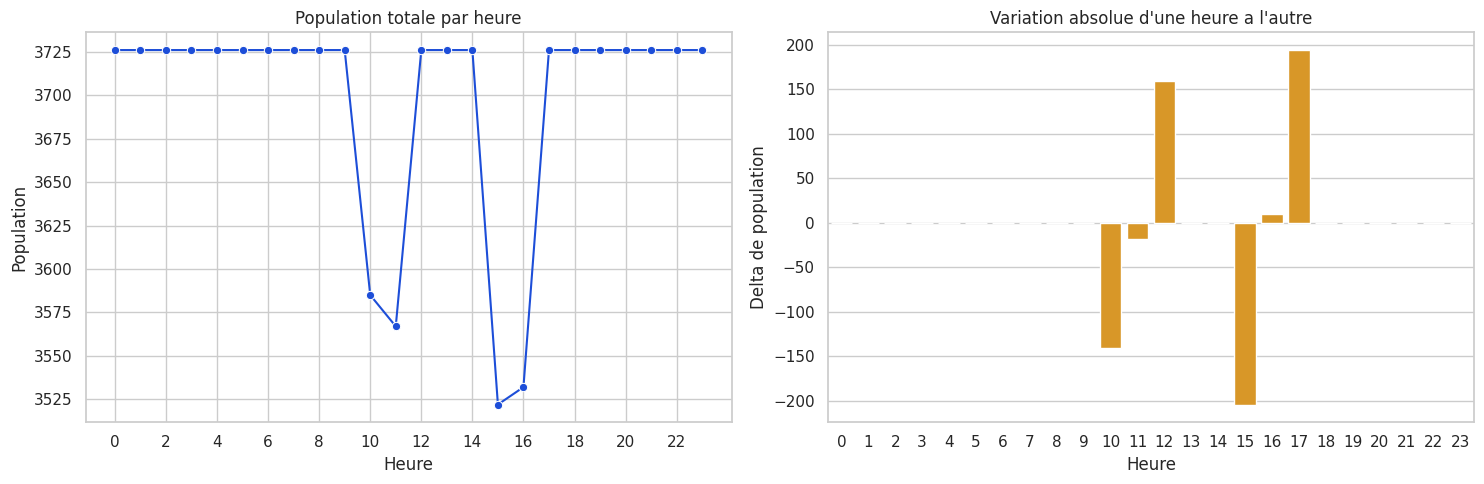

In [6]:
hourly = hourly_population_profile(gdf)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=hourly, x="hour", y="population", marker="o", color="#1d4ed8", ax=axes[0])
axes[0].set_title("Population totale par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Population")
axes[0].set_xticks(range(0, 24, 2))

sns.barplot(data=hourly, x="hour", y="delta_abs", color="#f59e0b", ax=axes[1])
axes[1].set_title("Variation absolue d'une heure a l'autre")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Delta de population")

plt.tight_layout()
plt.show()


## 4. Cibles demographiques versus roles realises

On compare ici les volumes cibles issus de `config.yaml` avec les volumes effectivement realises apres generation des foyers et reequilibrage.


,role,target_count,realized_count,target_share,realized_share,gap_count,gap_share_pp
0,scolaire,361,361,0.096887,0.096887,0,0.0
1,senior,1580,1580,0.424047,0.424047,0,0.0
2,actif_local,689,689,0.184917,0.184917,0,0.0
3,actif_navetteur,1096,1096,0.294149,0.294149,0,0.0


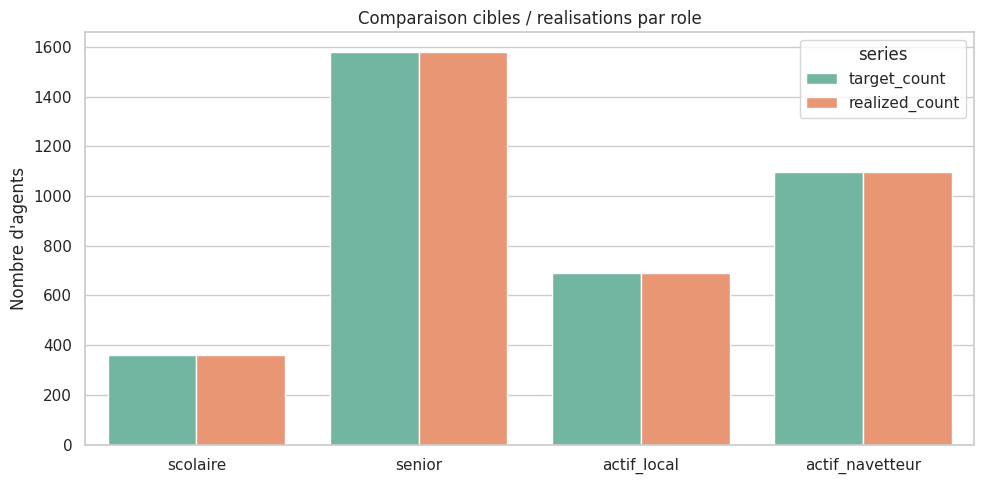

In [7]:
roles = role_targets_vs_realized(gdf, config)
display(roles)

roles_long = roles.melt(
    id_vars="role",
    value_vars=["target_count", "realized_count"],
    var_name="series",
    value_name="count",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=roles_long, x="role", y="count", hue="series", palette="Set2")
plt.title("Comparaison cibles / realisations par role")
plt.xlabel("")
plt.ylabel("Nombre d'agents")
plt.tight_layout()
plt.show()


## 5. Validation du non residentiel et du double comptage

Le tableau ci-dessous documente les volumes injectes hors residentiel et les corrections appliquees pour limiter le double comptage touristique/residentiel.


In [8]:
nonres = non_residential_validation(gdf)
display(nonres)


,component,population,batiments_concernes,part_de_pop_t0_pct
0,Hebergement touristique,53,8,1.42
1,Activites et equipements,0,0,0.0
2,Audit overlap - no_accommodation_source,4763,4763,None
3,Audit overlap - added_non_residential_building,8,8,None
4,Audit overlap - excluded_residential_overlap,6,6,None
5,Audit overlap - added_residential_additive_source,2,2,None


## 6. Occupation a T0 par type de batiment

Cette lecture aide a verifier si la population de l'etat initial repose bien sur des supports spatiaux plausibles.


,usage_1,population_t0,batiments
3,Résidentiel,3676,2263
1,Commercial et services,37,3
2,Indifférencié,12,2
0,Annexe,1,1


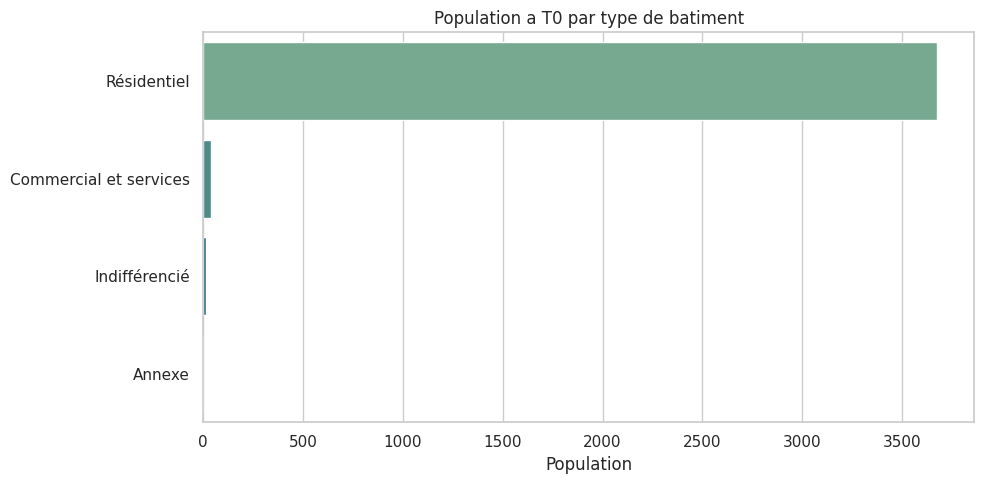

In [9]:
usage_t0 = occupied_buildings_by_usage(gdf).head(12)
display(usage_t0)

plt.figure(figsize=(10, 5))
sns.barplot(data=usage_t0, x="population_t0", y="usage_1", hue="usage_1", palette="crest", legend=False)
plt.title("Population a T0 par type de batiment")
plt.xlabel("Population")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 7. Batiments les plus variables sur 24h

On repere ici les entites dont l'amplitude horaire est la plus forte. C'est utile pour identifier les poles structurants du scenario.


,building_id,usage_1,min_pop,max_pop,amplitude,peak_hour
51,BATZ_BATIMENT0000000303010642,Résidentiel,1,9,8,h12
1226,BATZ_BATIMENT0000000303001087,Indifférencié,0,8,8,h12
1227,BATZ_BATIMENT0000000303001085,Indifférencié,0,8,8,h12
1416,BATZ_BATIMENT0000000303004460,Résidentiel,1,8,7,h13
3524,BATZ_BATIMENT0000000029148971,Indifférencié,0,7,7,h12
1421,BATZ_BATIMENT0000000303004458,Commercial et services,0,6,6,h12
923,BATZ_BATIMENT0000000303001508,Commercial et services,29,34,5,h0
1287,BATZ_BATIMENT0000000303003287,Résidentiel,1,6,5,h12
4119,BATZ_BATIMENT0000000303000151,Résidentiel,1,6,5,h12
1325,BATZ_BATIMENT0000000303004507,Commercial et services,0,5,5,h13


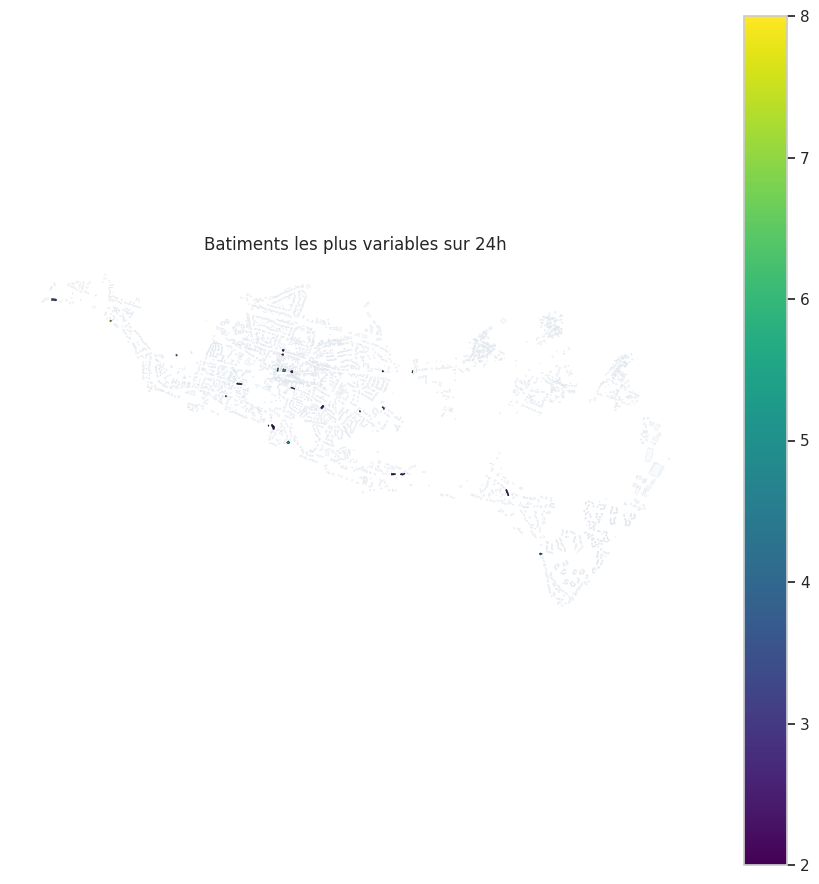

In [10]:
variation = temporal_variation_buildings(gdf, top_n=25)
display(variation[["building_id", "usage_1", "min_pop", "max_pop", "amplitude", "peak_hour"]].head(10))

fig, ax = plt.subplots(figsize=(9, 9))
gdf.plot(ax=ax, color="#f8fafc", edgecolor="#cbd5e1", linewidth=0.15)
variation.plot(ax=ax, column="amplitude", cmap="viridis", legend=True, edgecolor="#0f172a", linewidth=0.35)
ax.set_title("Batiments les plus variables sur 24h")
ax.axis("off")
plt.tight_layout()
plt.show()


## 8. Conclusion de lecture

Quelques questions a te poser en fin de notebook :
- le profil horaire global est-il coherent avec le scenario choisi ?
- les ecarts entre cibles et realisations de roles restent-ils faibles et explicables ?
- le non residentiel reste-t-il dans des ordres de grandeur plausibles ?
- les batiments les plus variables correspondent-ils bien aux poles attendus du territoire ?
